In [1]:
!#pip install matplotlib

# Meta Search Engine

- Aditya Chittella

In [2]:
#Import required libraries
import re
import string
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import datetime
import urllib
import datetime
from bs4 import BeautifulSoup
from itertools import islice
from dateutil.relativedelta import relativedelta
from datetime import timedelta
from datetime import datetime
import datetime


### Task 1: Document Extraction from a search engine

In [3]:
class MSE(object):
    
    def __init__(self, number_of_results=None, l_from_date=None, l_to_date=None):
        
        assert isinstance(number_of_results, int), 'Number of results must be an integer'
        if number_of_results is None:
            self.number_of_results = 20
        else:
            self.number_of_results = number_of_results
        
        self.dt_format = '%d/%m/%Y'
        
        if l_to_date is None:
            self.to_date_obj = datetime.datetime.now()
        else:
            self.to_date_obj = datetime.datetime.strptime(str(l_to_date), self.dt_format)
            self.to_date_obj = datetime.datetime.combine(self.to_date_obj.date(), datetime.time(23, 59, 59))

        if l_from_date is None:
            five_days_ago = (datetime.datetime.now() - timedelta(days=5))
            self.from_date_obj = datetime.datetime.combine(five_days_ago.date(), datetime.time(0, 0, 0))
        else:
            self.from_date_obj = datetime.datetime.strptime(str(l_from_date), self.dt_format)

        self.search_engine = 'Google'
        print("Args: " + str(self.number_of_results) + ", " + str(self.from_date_obj) + ", " + str(self.to_date_obj))

    def parse_google_html(self,category,html):
        
        soup = BeautifulSoup(html, 'html.parser')
        found_result = []
        position_in_search_result = 1
        result_block = soup.find_all('c-wiz', class_='PO9Zff')
        result_range = min(len(result_block), self.number_of_results)
        
        for result in result_block:

            link = result.find('a', class_='JtKRv')
            #Extract the title
            title = result.find('a', class_='JtKRv')
            snippet = None
            datetime_tag = result.find('time')
            datetime_str = datetime_tag['datetime']
            datetime_obj = datetime.datetime.strptime(str(datetime_str), '%Y-%m-%dT%H:%M:%SZ')

            #if link and title:
            if self.from_date_obj < datetime_obj < self.to_date_obj:
                if title:
                    link = link['href']
                    title = title.get_text()
                    if snippet:
                        snippet = snippet.get_text()
                        #print('snippet', snippet)
                    
                    #DateTime = re.split("T",time['datetime'])[0]
                    #print('DT', time['datetime'])
                    #print('G Categoty:', category)

                    found_result.append({
                                        'engine' : 'Google',
                                        'rank': position_in_search_result,
                                        'docid': 'G'+str(position_in_search_result),
                                        'category': category,
                                        'title': title,
                                        'snippet': snippet,                                    
                                        'DateTime': str(datetime_obj)
                                    }) 
                    position_in_search_result += 1
            if position_in_search_result > self.number_of_results:
                break
        print("Length of found_result" + str(len(found_result)))              
        return found_result

    def parse_bing_html(self, category, html):
        
        soup = BeautifulSoup(html, 'html.parser')
        found_result = []
        position_in_search_result = 1

        result_block = soup.find_all('div', class_='news-card')
        print(len(result_block))
        
        result_range = min(len(result_block), self.number_of_results)
        print('Result range : ' + str(result_range))

        #for index, result in zip(range(result_range), result_block):
        for result in result_block:

            title = result.find('a', class_='title')

            snippet = result.find('div', class_='snippet')
            
            datetime_tag = result.find('span', attrs={'aria-label': True})
            datetime_rel = datetime_tag['aria-label']

            try:
                datetime_obj = self.getpastdate(str(datetime_rel))
            except:
                continue

            
            if self.from_date_obj < datetime_obj < self.to_date_obj:

                #if link and title:
                if title:
              
                    title = title.get_text()
                    if snippet:
                        snippet = snippet.get_text()

                    found_result.append({
                                        'engine' : 'Google',
                                        'rank': position_in_search_result,
                                        'docid': 'B'+str(position_in_search_result),
                                        'title': title,
                                        'snippet': snippet,
                                        'category': category,
                                        'date_time' : str(datetime_obj)
                                    }) 
                    position_in_search_result += 1
            if position_in_search_result > self.number_of_results:
                break
        print("Length of found_result" + str(len(found_result)))
        return found_result
      
    def google_news(self, category, query, language_code = 'en'):
        search_url = self.get_search_query(category, query, 'en', 'Google')
        response = response_text = self.execute_search(search_url)
        parsed_result = self.parse_google_html(category, response)
        return parsed_result

    def bing_news(self, category, query, language_code = 'en-us'):
        search_url = self.get_search_query(category, query, language_code, 'Bing')
        response = response_text = self.execute_search(search_url)
        parsed_result = self.parse_bing_html(category, response)            
        return parsed_result

    def execute_search(self, search_url):
        USER_AGENT = {'User-Agent':'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/61.0.3163.100 Safari/537.36'}
        parsed_result = dict()
        response = ''
        response = requests.get(search_url, headers=USER_AGENT, verify=False)
        response.raise_for_status()
        return response.text

    def get_search_query(self, category, query, language, search_engine='Google'):
        search_url = ''
        if search_engine == 'Google':
            params = { 'q' : category + ' ' + query, 'hl' : language}
            search_url = "https://news.google.com/search?" + urllib.parse.urlencode(params)
        elif search_engine == 'Bing':
            params = { 'q' : category + ' ' + query, 'setlang' : language, 'count' : '100'}
            search_url = "https://www.bing.com/news/search?" + urllib.parse.urlencode(params)
        print("Search url : " + search_url)        
        return search_url
   
   
    def getpastdate(self, str_days_ago):
        TODAY = datetime.datetime.today()
        splitted = str_days_ago.split()
        if len(splitted) == 1 and splitted[0].lower() == 'today':
            return TODAY
        elif len(splitted) == 1 and splitted[0].lower() == 'yesterday':
            dt_obj = TODAY - relativedelta(days=1)
            return dt_obj
        elif splitted[1].lower() in ['minute', 'minutes', 'min', 'mins', 'm']:
            dt_obj = datetime.datetime.now() - relativedelta(minutes=int(splitted[0]))
            return dt_obj
        elif splitted[1].lower() in ['hour', 'hours', 'hr', 'hrs', 'h']:
            dt_obj = datetime.datetime.now() - relativedelta(hours=int(splitted[0]))
            return dt_obj
        elif splitted[1].lower() in ['day', 'days', 'd']:
            dt_obj = TODAY - relativedelta(days=int(splitted[0]))
            return dt_obj
        elif splitted[1].lower() in ['wk', 'wks', 'week', 'weeks', 'w']:
            dt_obj = TODAY - relativedelta(weeks=int(splitted[0]))
            return dt_obj
        elif splitted[1].lower() in ['mon', 'mons', 'month', 'months', 'm']:
            dt_obj = TODAY - relativedelta(months=int(splitted[0]))
            return dt_obj
        elif splitted[1].lower() in ['yrs', 'yr', 'years', 'year', 'y']:
            date = TODAY - relativedelta(years=int(splitted[0]))
            return dt_obj
        else:
            return datetime.datetime.strptime(str_days_ago, self.dt_format)
    
    def clean_text(self, text, title= False):
        if str(text) == 'nan' and type(text) != 'str':
            return ""
    
        if title:
            text = "".join([word for word in text if word not in string.punctuation])
        else:
            text = "".join([word.lower() for word in text if word not in string.punctuation])
        tokens = re.split('\W+', text)
        text = " ".join([word for word in tokens if word.isalpha()])
        return text  


In [4]:
company_name = input("enter the company name : ")
%store company_name

#del ipo_compay_name

Stored 'company_name' (str)


In [5]:
import os
dir_name=company_name

if not os.path.exists(dir_name):
    os.makedirs(dir_name)

In [6]:
from types import NoneType
top_n_result = 20
l_from_date='25/10/2020'
l_to_date='02/01/2021'

metasearchengine = MSE(top_n_result, None, None)

# google_results_business = metasearchengine.google_news('', company_name, 'en')
# bing_results_business = metasearchengine.bing_news('', company_name, 'en-us')

google_results_tech = metasearchengine.google_news('Technology', company_name, 'en')
bing_results_tech = metasearchengine.bing_news('Technology', company_name, 'en-us')
google_results_business = metasearchengine.google_news('Business', company_name, 'en')
bing_results_business = metasearchengine.bing_news('Business', company_name, 'en-us')

Args: 20, 2026-08-03 00:00:00, 2026-08-08 20:01:00.662807
Search url : https://news.google.com/search?q=Technology+Amazon&hl=en


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'news.google.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'news.google.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Length of found_result20
Search url : https://www.bing.com/news/search?q=Technology+Amazon&setlang=en-us&count=100


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'www.bing.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


14
Result range : 14
Length of found_result10
Search url : https://news.google.com/search?q=Business+Amazon&hl=en


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'news.google.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'news.google.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Length of found_result20
Search url : https://www.bing.com/news/search?q=Business+Amazon&setlang=en-us&count=100


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'www.bing.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


14
Result range : 14
Length of found_result5


In [7]:
pd_google_results_business = pd.DataFrame(google_results_business, columns=['engine', 'rank', 'docid', 'category', 'title', 'snippet', 'DateTime'])
pd_bing_results_business = pd.DataFrame(bing_results_business, columns=['engine', 'rank', 'docid', 'title', 'snippet', 'category', 'date_time'])


In [8]:
pd_google_results_tech = pd.DataFrame(google_results_tech, columns=['engine', 'rank', 'docid', 'category', 'title', 'snippet', 'DateTime'])
pd_bing_results_tech = pd.DataFrame(bing_results_tech, columns=['engine', 'rank', 'docid', 'title', 'snippet', 'category', 'date_time'])

In [9]:
pd_google_results_tech.head()

,engine,rank,docid,category,title,snippet,DateTime
0,Google,1,G1,Technology,TECHNOLOGY/INTERNET—9th Cir.: Amazon’s unlawfu...,None,2026-08-07 21:55:37
1,Google,2,G2,Technology,Amazon's AI Warehouses Are Struggling With A R...,None,2026-08-08 13:17:00
2,Google,3,G3,Technology,Why Amazon’s $3 Trillion Valuation Signals a N...,None,2026-08-05 12:33:02
3,Google,4,G4,Technology,"Leases totalling $1 trillion from Microsoft, M...",None,2026-08-05 12:31:00
4,Google,5,G5,Technology,"Amazon drops Samsung Galaxy S26 price by 14,00...",None,2026-08-06 14:07:15


In [10]:
pd_bing_results_tech.head()

,engine,rank,docid,title,snippet,category,date_time
0,Google,1,B1,Amazon’s AI Spending Keeps Rising. Andy Jassy ...,Amazon has increased its planned capital spend...,Technology,2026-08-08 07:01:02.975046
1,Google,2,B2,Amazon's AI warehouses are struggling with a r...,"AI is everywhere, including at one of the worl...",Technology,2026-08-08 19:01:02.975257
2,Google,3,B3,"From GPS tracking to SOS alerts, these kids sm...",Looking for a smartwatch for your child? The A...,Technology,2026-08-08 12:01:02.975421
3,Google,4,B4,Amazon becomes a $3 trillion company: What's d...,Amazon has become the fifth company to cross t...,Technology,2026-08-04 20:01:02.975713
4,Google,5,B5,"Amazon ‘rewarded’ after AI investment plans, b...",Amazon achieved a significant financial milest...,Technology,2026-08-04 20:01:02.975861


In [11]:
pd_google_results_business.head()

,engine,rank,docid,category,title,snippet,DateTime
0,Google,1,G1,Business,Amazon Business: How Procurement Teams Shape S...,None,2026-08-07 10:57:45
1,Google,2,G2,Business,"Amazon is Worth $3 Trillion Again. But AI, Not...",None,2026-08-06 11:16:12
2,Google,3,G3,Business,Amazon behind massive private gas plant for ne...,None,2026-08-08 08:33:14
3,Google,4,G4,Business,Celebrating National Handloom Day: 7 textiles ...,None,2026-08-06 10:18:11
4,Google,5,G5,Business,Internal Amazon documents reveal a major overh...,None,2026-08-06 09:00:00


In [12]:
pd_bing_results_business.head()

,engine,rank,docid,title,snippet,category,date_time
0,Google,1,B1,"Why more than 40 companies, including Amazon, ...","More than 40 companies, including Amazon, Meta...",Business,2026-08-06 20:01:05.565024
1,Google,2,B2,Less than a fifth of India’s MSME procurement ...,According to the India Digital Procurement Rep...,Business,2026-08-07 20:01:05.565241
2,Google,3,B3,Amazon's Stock Just Soared 15%. Here's Why Now...,Amazon (NASDAQ: AMZN) stock soared 15% after i...,Business,2026-08-08 15:01:05.565426
3,Google,4,B4,Amazon's $3 Trillion Explained: The AI Cloud B...,"Amazon just hit 3 trillion in market value, an...",Business,2026-08-06 20:01:05.565909
4,Google,5,B5,Amazon joins the $3 trillion club as AWS chief...,Amazon has crossed a $3 trillion market cap fo...,Business,2026-08-04 20:01:05.567025


In [13]:
pd_google_results_tech['title_snippet'] = pd_google_results_tech['title'].fillna('')+' '+pd_google_results_tech['snippet'].fillna('')
pd_bing_results_tech['title_snippet'] = pd_bing_results_tech['title'].fillna('')+' '+pd_bing_results_tech['snippet'].fillna('')

pd_google_results_business['title_snippet'] = pd_google_results_business['title'].fillna('')+' '+pd_google_results_business['snippet'].fillna('')
pd_bing_results_business['title_snippet'] = pd_bing_results_business['title'].fillna('')+' '+pd_bing_results_business['snippet'].fillna('')

In [14]:
#Normalize and clean the text
pd_google_results_tech['title_snippet'] = pd_google_results_tech['title_snippet'].apply(lambda x: metasearchengine.clean_text(x))
pd_bing_results_tech['title_snippet'] = pd_bing_results_tech['title_snippet'].apply(lambda x: metasearchengine.clean_text(x))
pd_google_results_business['title_snippet'] = pd_google_results_business['title_snippet'].apply(lambda x: metasearchengine.clean_text(x))
pd_bing_results_business['title_snippet'] = pd_bing_results_business['title_snippet'].apply(lambda x: metasearchengine.clean_text(x))

In [15]:
#Select top n results
pd_google_results_tech = pd_google_results_tech.loc[:top_n_result-1,:]
pd_bing_results_tech = pd_bing_results_tech.loc[:top_n_result-1,:]
pd_google_results_business = pd_google_results_business.loc[:top_n_result-1,:]
pd_bing_results_business = pd_bing_results_business.loc[:top_n_result-1,:]

In [16]:
google_result_tech = pd_google_results_tech.loc[:,['docid', 'title_snippet']]
bing_result_tech = pd_bing_results_tech.loc[:,['docid', 'title_snippet']]
google_result_business = pd_google_results_business.loc[:,['docid', 'title_snippet']]
bing_result_business = pd_bing_results_business.loc[:,['docid', 'title_snippet']]

In [17]:
google_result_tech.head()

,docid,title_snippet
0,G1,technologyinternet cir amazon s unlawful acces...
1,G2,amazons ai warehouses are struggling with a re...
2,G3,why amazon s trillion valuation signals a new ...
3,G4,leases totalling trillion from microsoft meta ...
4,G5,amazon drops samsung galaxy price by by rs bef...


In [18]:
bing_result_tech.head()

,docid,title_snippet
0,B1,amazon s ai spending keeps rising andy jassy s...
1,B2,amazons ai warehouses are struggling with a re...
2,B3,from gps tracking to sos alerts these kids sma...
3,B4,amazon becomes a trillion company whats drivin...
4,B5,amazon rewarded after ai investment plans beco...


In [19]:
# from google.colab import drive
# drive.mount('/content/gdrive')

In [20]:
#%cd /content/gdrive/MyDrive/Colab Notebooks/IR Assignment/Final code


In [21]:
query = company_name
google_result_tech.to_csv(dir_name+"/"+query+'_google_tech.txt', sep='\t', index=False)
bing_result_tech.to_csv(dir_name+"/"+query+'_bing_tech.txt', sep='\t', index=False)
google_result_business.to_csv(dir_name+"/"+query+'_google_business.txt', sep='\t', index=False)
bing_result_business.to_csv(dir_name+"/"+query+'_bing_business.txt', sep='\t', index=False)

# Task 2: Aggregated News Collection

In [22]:
#Concatenate both the result
search_result = pd.concat([pd_google_results_tech, pd_bing_results_tech, pd_google_results_business, pd_bing_results_business], ignore_index=True)
#Remove the duplicate results using title column
search_result = search_result[~search_result['title'].duplicated()]

print('%d total search results after removing the duplicates.'%search_result.shape[0])

#Create new rank for the results
search_result['new_rank'] = [r for r in range(1,search_result.shape[0]+1)]

#Extract only required columns
aggregated_doc = search_result.loc[:,['new_rank','docid', 'title_snippet']]
aggregated_doc.head(40)

51 total search results after removing the duplicates.


,new_rank,docid,title_snippet
0,1,G1,technologyinternet cir amazon s unlawful acces...
1,2,G2,amazons ai warehouses are struggling with a re...
2,3,G3,why amazon s trillion valuation signals a new ...
3,4,G4,leases totalling trillion from microsoft meta ...
4,5,G5,amazon drops samsung galaxy price by by rs bef...
5,6,G6,inside amazons firstever drone delivery site i...
6,7,G7,watch amazons zoox robotaxi enters the commerc...
7,8,G8,xech unveils celebrate freedom upgrade life ca...
8,9,G9,amazon great freedom sale top android tablet d...
9,10,G10,amazon delivery drones are coming to metro atl...


In [23]:
#Write the agreegated result to the text file
aggregated_doc.to_csv(dir_name+"/"+'RankedDocuments.txt', sep='\t', index=False)

# Task 3: Ranking

##### Approach 1

Sorted the result based on the rank of meta search result, if 2 search results are same, then the rank of Google search result given priority


In [24]:
search_result.head()

,engine,rank,docid,category,title,snippet,DateTime,title_snippet,date_time,new_rank
0,Google,1,G1,Technology,TECHNOLOGY/INTERNET—9th Cir.: Amazon’s unlawfu...,None,2026-08-07 21:55:37,technologyinternet cir amazon s unlawful acces...,NaN,1
1,Google,2,G2,Technology,Amazon's AI Warehouses Are Struggling With A R...,None,2026-08-08 13:17:00,amazons ai warehouses are struggling with a re...,NaN,2
2,Google,3,G3,Technology,Why Amazon’s $3 Trillion Valuation Signals a N...,None,2026-08-05 12:33:02,why amazon s trillion valuation signals a new ...,NaN,3
3,Google,4,G4,Technology,"Leases totalling $1 trillion from Microsoft, M...",None,2026-08-05 12:31:00,leases totalling trillion from microsoft meta ...,NaN,4
4,Google,5,G5,Technology,"Amazon drops Samsung Galaxy S26 price by 14,00...",None,2026-08-06 14:07:15,amazon drops samsung galaxy price by by rs bef...,NaN,5


In [25]:
search_result = search_result.sort_values(['rank', 'engine'], ignore_index=True)

#Create new rank for approach 1 results
search_result['new_rank'] = [r for r in range(1,search_result.shape[0]+1)]
approach_1_result = search_result.loc[:,['new_rank', 'docid', 'title_snippet']]

approach_1_result.head(20)

,new_rank,docid,title_snippet
0,1,G1,technologyinternet cir amazon s unlawful acces...
1,2,B1,amazon s ai spending keeps rising andy jassy s...
2,3,G1,amazon business how procurement teams shape st...
3,4,B1,why more than companies including amazon meta ...
4,5,G2,amazons ai warehouses are struggling with a re...
5,6,B2,amazons ai warehouses are struggling with a re...
6,7,G2,amazon is worth trillion again but ai not ecom...
7,8,B2,less than a fifth of india s msme procurement ...
8,9,G3,why amazon s trillion valuation signals a new ...
9,10,B3,from gps tracking to sos alerts these kids sma...


In [26]:
#Write the new rank details based on approach 1 to the text file
approach_1_result.to_csv(dir_name+"/"+company_name+'_ResultantRanks_A1.txt', sep='\t', index=False)

##### Approach 2

In [27]:
def term_frequency(qi, d):
    return d.count(qi)/len(d.split())
    
def compute_rank(query, d):    
    alpha = 2
    rel = 1
    ld = len(d.split())
    for qi in query.split():
        rel = rel * (0.5 *((term_frequency(qi, d)/ld) * alpha))
        
    return rel

In [28]:
search_result['rank_approach2'] = search_result['title_snippet'].apply(lambda d: compute_rank(metasearchengine.clean_text(query) ,d))
search_result = search_result.sort_values(['rank_approach2'], ascending=False,  ignore_index=True)

#Create new rank for the search result for approach 2
search_result['new_rank'] = [r for r in range(1,search_result.shape[0]+1)]
approach_2_result = search_result.loc[:,['new_rank', 'docid', 'title_snippet']]
approach_2_result.head()

,new_rank,docid,title_snippet
0,1,G7,amazon business optimising inventory with mach...
1,2,G17,amazon dropshipping guide for businesses in af...
2,3,G1,amazon business how procurement teams shape st...
3,4,G7,watch amazons zoox robotaxi enters the commerc...
4,5,G10,amazon delivery drones are coming to metro atl...


In [29]:
approach_2_result.tail()

,new_rank,docid,title_snippet
46,47,B6,from quiet evenings to loud celebrations your ...
47,48,B3,from gps tracking to sos alerts these kids sma...
48,49,B2,less than a fifth of india s msme procurement ...
49,50,B5,amazon joins the trillion club as aws chief ca...
50,51,B2,amazons ai warehouses are struggling with a re...


In [30]:
#Write the new rank details based on approach 2 to the text file
approach_2_result.to_csv(dir_name+"/"+company_name+'_ResultantRanks_A2.txt', sep='\t', index=False)

# Task 4: Evaluation

**Assumtion**: Aggregated result (UniqueDocuments.txt) will play the role of manually assigned document

In [31]:
precision_stage = [5, 10, 15, 20, 25, 30]
precision_at_stage_approach1, precision_at_stage_approach2 = list(), list()

In [32]:
def pre_at_stage(manual_ranked_doc, rank_gen_doc, top_n):
    
    precision = 0
    
    manual_doc_re = np.array(manual_ranked_doc.loc[:top_n-1,['docid']])
    app_re = np.array(rank_gen_doc.loc[:top_n-1,['docid']])
    
    for doc_id in app_re:
        if doc_id in manual_doc_re:
            precision += 1
    
    return precision/top_n

###### 1. Find the values for Precision@K, where k is 5, 10, 15, 20, 25, 30

In [33]:
for pre_stage in precision_stage:    
    precision_at_stage_approach1.append(pre_at_stage(aggregated_doc, approach_1_result, pre_stage))
    
for pre_stage in precision_stage:    
    precision_at_stage_approach2.append(pre_at_stage(aggregated_doc, approach_2_result, pre_stage))

###### 2. Plot the values for Precision@k, , where k is 5, 10, 15, 20, 25, 30

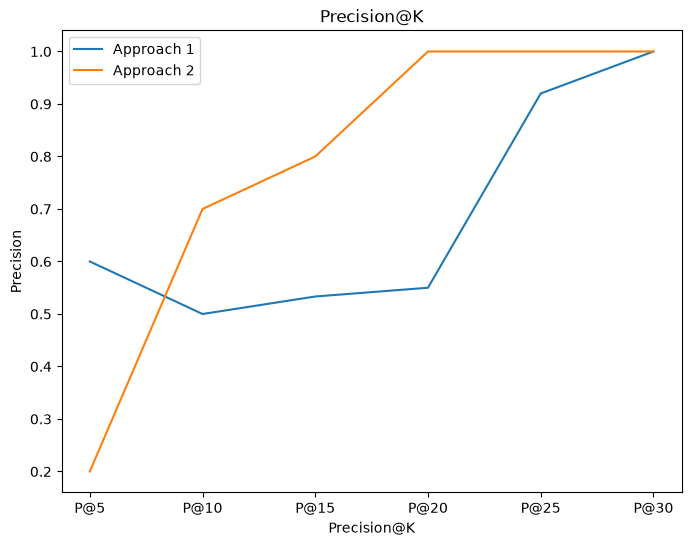

In [34]:
plt.figure(figsize=(8,6))
plt.plot(precision_stage, precision_at_stage_approach1)
plt.plot(precision_stage, precision_at_stage_approach2)
plt.legend(['Approach 1', 'Approach 2'])
plt.xticks(precision_stage, ['P@'+str(pre_stage) for pre_stage in precision_stage])
plt.title('Precision@K')
plt.xlabel('Precision@K')
plt.ylabel('Precision')
plt.show()

###### 3. Mean Average Precision(MAP) for Approach 1 and Approach 2

In [35]:
print('Mean Average Precision(MAP) for Approach 1 is %.2f'%(sum(precision_at_stage_approach1)/len(precision_at_stage_approach1)))
print('Mean Average Precision(MAP) for Approach 2 is %.1f'%(sum(precision_at_stage_approach2)/len(precision_at_stage_approach2)))

Mean Average Precision(MAP) for Approach 1 is 0.68
Mean Average Precision(MAP) for Approach 2 is 0.8
